# Problema de la mochila

bela gallardo ing fernandez

# Problema del agente viajero

Dado un grafo no dirigido y con pesos $G = (V, A)$ encontrar un ciclo simple de costo mínimo que pase por todos los nodos.

Características:
- Es un problema NP (No polinomial), pero necesitamos una solución eficiente.
Posibilidades:
1. **Los nodos son los candidatos**. Empezar en un nodo cualquiera. En cada paso moverse al nodo no visitado más próximo al último nodo seleccionado.


# Recocido simulado (simulated annealing)

- Hacer este problema para que podamos hacer que el intervalo sea de cierta profundidad de bits (no solo la normal)
- Hacer un análisis de sensibilización de parámetros.
Definir la función de temperatura para este algoritmo.

# Investigación:
- Funciones de De Jong para computo

In [39]:
import numpy as np
import random
import matplotlib.pyplot as plt
import math

In [3]:
def T_lineal(T, a, b):
    return a * T + b

In [59]:
def fun(x):
    return -x**4 + 23*x**2 - 1234*x + 1

In [27]:
def Boltzman_func(delta_E, T):
    k = 1
    return np.exp(-delta_E/(k * T))

In [53]:
def Recocido_1D(s_0, T_max, T_min, func, intervalo, alpha=0.95, iter_por_T=10):
    """
    s_0: Solución inicial
    T_max: Temperatura inicial
    T_min: Temperatura de paro (criterio de detención)
    func: Función objetivo a evaluar
    intervalo: Rango para buscar vecinos aleatorios
    alpha: Tasa de enfriamiento
    iter_por_T: Número de iteraciones en una misma temperatura
    """
    T = T_max
    s_actual = s_0
    mejor_s = s_actual # Guardamos registro de la mejor solución global encontrada
    
    # Mientras no se cumpla el criterio de paro (T < T_min) el bucle sigue
    while T >= T_min:
        
        # Bucle interior: Repetir a una temperatura fija
        for _ in range(iter_por_T):
            # Generar un vecino aleatorio
            s_prime = random.uniform(s_actual - intervalo, s_actual + intervalo)
            
            # Calcular delta_E
            delta_E = func(s_prime) - func(s_actual)
            
            # Si delta_E <= 0, se acepta la nueva solución
            if delta_E <= 0:
                s_actual = s_prime
                # Si además es la mejor solución histórica, la guardamos
                if func(s_actual) < func(mejor_s): 
                    mejor_s = s_actual
            else:
                # Si delta_E > 0, calcular probabilidad de Boltzmann
                # P(delta_E) = e^(-delta_E / T)  (Asumiendo k=1 para simplificar)
                probabilidad = math.exp(-delta_E / T)
                
                # Comparar con un número aleatorio de 0 a 1
                if random.random() < probabilidad:
                    s_actual = s_prime # Se acepta la peor solución
                    
        # Actualización de la temperatura (Enfriamiento)
        T = T * alpha 
        
    # Output: Mejor solución encontrada
    return mejor_s

In [54]:
maximo = Recocido_1D(10, 100, 10, fun, 10, 0.95, 10)

In [55]:
print(maximo)

6.257640101987578


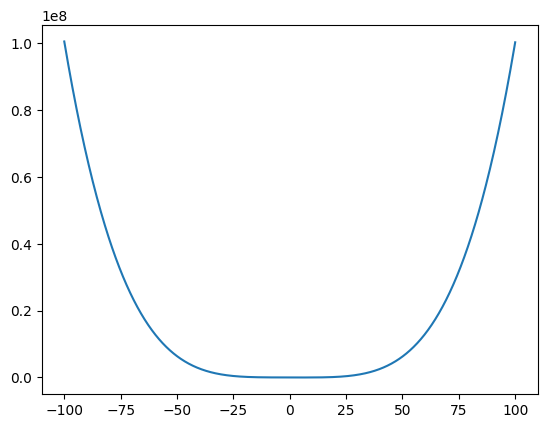

In [56]:
x = np.linspace(-100, 100, 1000)
plt.plot(x, fun(x))
plt.show()

In [64]:
def Recocido_1D_Grafico(s_0, T_max, T_min, func, intervalo, x_min, x_max, alpha=0.95, iter_por_T=10):
    """
    Función de Recocido Simulado que minimiza una función y grafica el proceso.
    """
    T = T_max
    s_actual = s_0
    mejor_s = s_actual
    
    # Listas para guardar el historial y graficar después
    aceptados_x = []
    aceptados_y = []
    rechazados_x = []
    rechazados_y = []
    
    # Guardamos el punto inicial como aceptado
    aceptados_x.append(s_actual)
    aceptados_y.append(func(s_actual))
    
    while T >= T_min:
        for _ in range(iter_por_T):
            # Generar un vecino aleatorio dentro de los límites
            s_prime = random.uniform(s_actual - intervalo, s_actual + intervalo)
            
            # Mantener el vecino dentro de los límites de búsqueda globales
            s_prime = max(min(s_prime, x_max), x_min)
            
            # Calcular delta_E
            delta_E = func(s_prime) - func(s_actual)
            
            # Evaluar aceptación
            aceptado = False
            if delta_E <= 0: # Si la energía es menor o igual, se acepta
                aceptado = True
                if func(s_prime) > func(mejor_s): ## Modificar si queremos minimo o máximo
                    mejor_s = s_prime
            else:
                # Si delta_E > 0, evaluar probabilidad de Boltzmann
                probabilidad = math.exp(-delta_E / T)
                if random.random() < probabilidad: # Comparar con número aleatorio
                    aceptado = True
            
            # Actualizar estado y guardar en el historial correspondiente
            if aceptado:
                s_actual = s_prime
                aceptados_x.append(s_actual)
                aceptados_y.append(func(s_actual))
            else:
                rechazados_x.append(s_prime)
                rechazados_y.append(func(s_prime))
                
        # Enfriamiento / Disminución de la temperatura
        T = T * alpha 
        
    # --- Graficas ---
    
    # Crear un arreglo de X para dibujar la función objetivo de fondo
    x_vals = np.linspace(x_min, x_max, 500)
    y_vals = [func(x) for x in x_vals]
    
    plt.figure(figsize=(10, 6))
    
    # 1. Graficar la función objetivo continua
    plt.plot(x_vals, y_vals, color='black', alpha=0.5, label='Función Objetivo $F(x)$')
    
    # 2. Graficar los puntos rechazados (Rojos)
    plt.scatter(rechazados_x, rechazados_y, color='red', marker='x', alpha=0.6, label='Rechazados')
    
    # 3. Graficar los puntos aceptados (Verdes) y unirlos con una línea punteada
    plt.plot(aceptados_x, aceptados_y, color='green', marker='o', linestyle=':', alpha=0.7, label='Aceptados (Trayectoria)')
    
    # 4. Marcar el inicio y el mejor punto encontrado
    plt.scatter(s_0, func(s_0), color='blue', s=100, zorder=5, label='Punto Inicial')
    plt.scatter(mejor_s, func(mejor_s), color='gold', edgecolors='black', s=150, zorder=5, marker='*', label='Óptimo Encontrado')
    
    plt.title('Simulación de Recocido Simulado (Minimización)')
    plt.xlabel('x')
    plt.ylabel('F(x)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return mejor_s

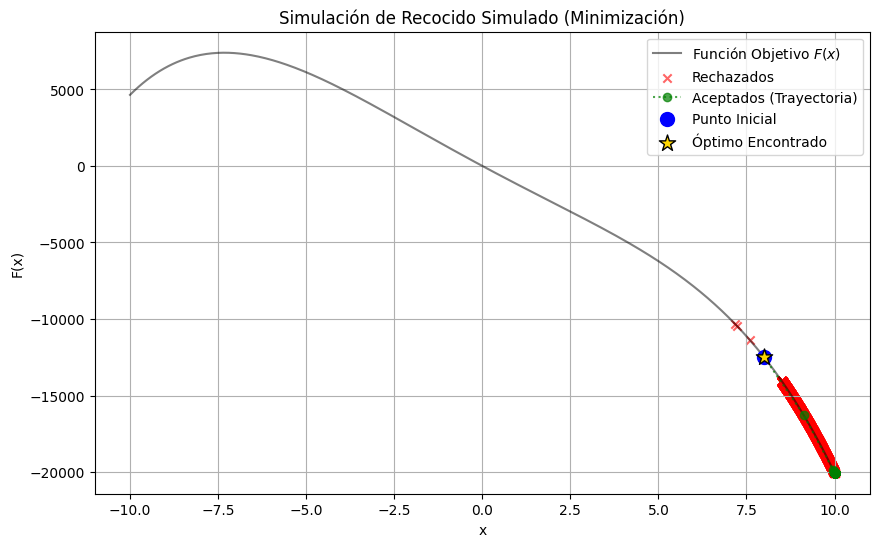

In [65]:
# Parámetros iniciales
punto_inicial = 8.0     # Empezamos lejos del óptimo global
temp_maxima = 50.0      # Temperatura alta al inicio
temp_minima = 0.1       # Temperatura de paro
tamano_paso = 1.5       # Qué tan lejos puede saltar a un vecino
limite_inf = -10.0      # Límite izquierdo de la gráfica
limite_sup = 10.0       # Límite derecho de la gráfica

mejor_resultado = Recocido_1D_Grafico(
    s_0 = punto_inicial,
    T_max = temp_maxima,
    T_min = temp_minima,
    func = fun,
    intervalo = tamano_paso,
    x_min = limite_inf,
    x_max = limite_sup,
    alpha = 0.99,       # Tasa de enfriamiento
    iter_por_T = 15     # Intentos por cada nivel de temperatura
)

Ejecutando Recocido Simulado...


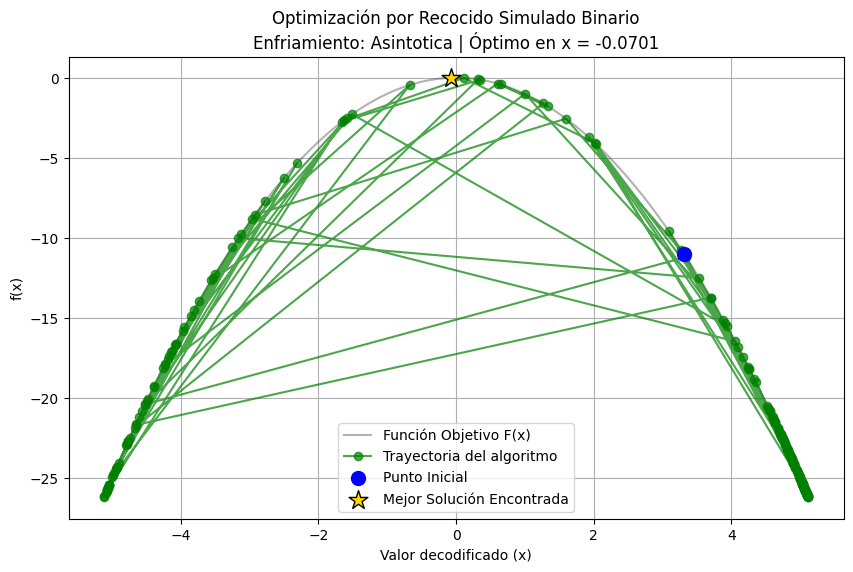


--- Resultados Finales ---
Mejor cadena binaria : [0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1]
Valor decodificado x : -0.070079
Mejor valor f(x)     : -0.004911


In [ ]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# FUNCIONES AUXILIARES
# ==========================================

def decodificar_binario(bits, a, b):
    """
    Convierte una lista de bits a un valor real en el intervalo [a, b].
    """
    n = len(bits)
    # Convertir lista de bits a string y luego a entero decimal
    decimal = int("".join(str(bit) for bit in bits), 2)
    # Interpolar en el intervalo [a, b]
    return a + decimal * (b - a) / ((2**n) - 1)

def de_jong_1(x):
    """
    Función objetivo: Polinomio de De Jong 1 (Esfera) en 1D.
    f(x) = x^2
    """
    return -x**2

# ==========================================
# ALGORITMO DE RECOCIDO SIMULADO (BINARIO)
# ==========================================

def Recocido_Binario(n_bits, a, b, func, minimizar=True, 
                     T_max=100.0, epsilon=0.01, tol=1e-4, 
                     tipo_temp='asintotica', alpha=0.1, iter_por_T=10):
    
    # 1. Generar solución inicial aleatoria en formato binario
    s_actual_bits = [random.choice([0, 1]) for _ in range(n_bits)]
    s_actual_x = decodificar_binario(s_actual_bits, a, b)
    
    mejor_bits = list(s_actual_bits)
    mejor_x = s_actual_x
    
    T = T_max
    k = 1 # Contador de épocas para la temperatura asintótica
    
    # Historial para graficar (inciso c)
    historial_x = [s_actual_x]
    historial_y = [func(s_actual_x)]
    
    # Variable para evaluar tolerancia (Sol(i-1))
    s_anterior_x = s_actual_x + tol * 10 # Forzamos a que no se cumpla la tolerancia en la iteración 1
    
    # T > epsilon (temperatura minima) Y la diferencia entre soluciones es mayor a la Tolerancia
    while T > epsilon and abs(s_actual_x - s_anterior_x) >= tol:
        
        s_anterior_x = s_actual_x # Guardamos la solución de la época anterior
        
        # Bucle interno a temperatura constante
        for _ in range(iter_por_T):
            # Generar vecino: "Flip" de un bit aleatorio
            s_vecino_bits = list(s_actual_bits)
            idx = random.randint(0, n_bits - 1)
            s_vecino_bits[idx] = 1 - s_vecino_bits[idx] # Cambia 0 a 1, o 1 a 0
            
            s_vecino_x = decodificar_binario(s_vecino_bits, a, b)
            
            # Calcular delta E
            delta_E = func(s_vecino_x) - func(s_actual_x)
            
            # Ajuste para maximizar (inciso inicial)
            if not minimizar:
                delta_E = -delta_E 
            
            # Como solo podemos aceptar si es deltaE <= 0 o la ec de Woltzman lo permite
            aceptado = False
            # Criterio de aceptación
            if delta_E <= 0:
                aceptado = True
                # Evaluar si es el mejor histórico
                if (minimizar and func(s_vecino_x) > func(mejor_x)) or \
                   (not minimizar and func(s_vecino_x) < func(mejor_x)): ## Modificar si queremos minimo o máximo
                    mejor_bits = list(s_vecino_bits)
                    mejor_x = s_vecino_x
            else:
                probabilidad = math.exp(-delta_E / T)
                if random.random() < probabilidad:
                    aceptado = True
            
            # Si se acepta, el vecino se vuelve la solución actual
            if aceptado:
                s_actual_bits = list(s_vecino_bits)
                s_actual_x = s_vecino_x
                
        # Guardar solución representativa de esta época para la gráfica
        historial_x.append(s_actual_x)
        historial_y.append(func(s_actual_x))
        
        # Actualización de Temperatura (inciso b)
        if tipo_temp == 'lineal':
            # T = T - alpha
            T = T - alpha
        elif tipo_temp == 'asintotica':
            # T = T0 / (1 + alpha * k)
            T = T_max / (1 + alpha * k)
            
        k += 1 # Incrementar época

    # --- SECCIÓN DE GRAFICACIÓN (inciso c) ---
    x_vals = np.linspace(a, b, 500)
    y_vals = [func(x) for x in x_vals]
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, y_vals, color='black', alpha=0.3, label='Función Objetivo F(x)')
    
    # Trazar el movimiento (trayectoria)
    plt.plot(historial_x, historial_y, color='green', marker='o', linestyle='-', alpha=0.7, label='Trayectoria del algoritmo')
    
    # Marcar inicio y fin
    plt.scatter(historial_x[0], historial_y[0], color='blue', s=100, zorder=5, label='Punto Inicial')
    plt.scatter(mejor_x, func(mejor_x), color='gold', edgecolors='black', s=200, zorder=5, marker='*', label='Mejor Solución Encontrada')
    
    plt.title(f'Optimización por Recocido Simulado Binario\nEnfriamiento: {tipo_temp.capitalize()} | Óptimo en x = {mejor_x:.4f}')
    plt.xlabel('Valor decodificado (x)')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return mejor_x, func(mejor_x), mejor_bits

# ==========================================
# EJECUCIÓN DE PRUEBA
# ==========================================

print("Ejecutando Recocido Simulado...")
mejor_valor_x, mejor_f_x, cadena_binaria = Recocido_Binario(
    n_bits = 16,            # Longitud de la cadena binaria
    a = -5.12,              # Límite inferior (Estándar para De Jong)
    b = 5.12,               # Límite superior
    func = de_jong_1,       # Función a optimizar
    minimizar = True,       # True para Minimizar, False para Maximizar
    T_max = 200.0,          # Temperatura inicial
    epsilon = 0.001,        # Criterio de parada por enfriamiento (épsilon)
    tol = 1e-4,             # Criterio de parada por tolerancia de cambio
    tipo_temp = 'asintotica', # 'lineal' o 'asintotica'
    alpha = 0.5,            # Tasa de decaimiento
    iter_por_T = 15         # Vecinos evaluados por nivel de temperatura
)

print(f"\n--- Resultados Finales ---")
print(f"Mejor cadena binaria : {cadena_binaria}")
print(f"Valor decodificado x : {mejor_valor_x:.6f}")
print(f"Mejor valor f(x)     : {mejor_f_x:.6f}")